<a href="https://colab.research.google.com/github/ssykes-eth/ETH_273-0003-00L/blob/weekend_2/Flag%20Diffusion%20CX/flag_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diffusion Models on Country Flag Colors

Each flag is encoded as an **11-dimensional vector**:

    x = [R1, G1, B1,  R2, G2, B2,  R3, G3, B3,  orientation,  n_colors]
         |--- color 1 ---|--- color 2 ---|--- color 3 ---|    |          |
                                                           0=horiz    0=two colors
                                                           1=vert     1=three colors

For 2-color flags, color3 = color1 (the flag repeats the first stripe).

Flag colors come from a small palette (red, white, blue, green, yellow, black),
so flags live on a **low-dimensional manifold** inside 11D space.

We will:
1. Fabricate a dataset of flag-like vectors
2. Train a tiny diffusion model on it
3. Generate new plausible flags from pure noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
# ── Canonical flag color palette (normalized RGB in [0, 1]) ──────────────────
RED    = [0.80, 0.10, 0.10]
WHITE  = [0.95, 0.95, 0.95]
BLUE   = [0.05, 0.20, 0.65]
GREEN  = [0.05, 0.55, 0.15]
YELLOW = [0.95, 0.80, 0.05]
BLACK  = [0.08, 0.08, 0.08]

# ── ~30 seed color triplets inspired by real flags ────────────────────────────
color_seeds = [
    RED   + WHITE  + BLUE,    # France / Netherlands
    BLUE  + WHITE  + RED,     # Czech Republic style
    GREEN + WHITE  + RED,     # Italy / Hungary
    RED   + YELLOW + RED,     # Spain
    BLACK + RED    + YELLOW,  # Germany
    GREEN + BLACK  + RED,     # Kenya
    RED   + WHITE  + RED,     # Japan-style (repeat)
    BLUE  + YELLOW + BLUE,    # Ukraine
    GREEN + YELLOW + RED,     # Pan-African (Ghana)
    RED   + GREEN  + YELLOW,  # Ethiopia
    WHITE + RED    + WHITE,   # Denmark-style
    BLUE  + WHITE  + BLUE,    # Greece-style
    GREEN + WHITE  + GREEN,   # Nigeria-style
    YELLOW + BLACK + YELLOW,  # Brunei-style
    RED   + WHITE  + GREEN,   # Iran / Mexico
    BLACK + YELLOW + RED,     # Belgium
    BLUE  + RED    + WHITE,   # USA variant
    RED   + BLUE   + WHITE,   # UK variant
    GREEN + RED    + BLACK,   # Palestinian variant
    WHITE + BLUE   + WHITE,   # Argentina-style
    YELLOW + RED   + GREEN,   # Vietnam-style
    RED   + BLACK  + GREEN,   # Libya-style
    BLUE  + WHITE  + GREEN,   # Estonia-style
    GREEN + WHITE  + BLUE,    # Sierra Leone-style
    WHITE + GREEN  + RED,     # Lebanon variant
    BLACK + GREEN  + YELLOW,  # Jamaica
    RED   + WHITE  + BLACK,   # UAE variant
    YELLOW + GREEN + RED,     # Bolivia-style
    BLUE  + GREEN  + WHITE,   # Gabon-style
    RED   + YELLOW + BLACK,   # Vietnam-style dark
]
color_seeds = np.array(color_seeds, dtype=np.float32)  # (30, 9)

# ── Augment: 12 noisy copies per seed, randomly assign orientation & n_colors ─
copies = []
for s in color_seeds:
    for _ in range(12):
        noisy = np.clip(s + np.random.randn(9).astype(np.float32) * 0.03, 0.0, 1.0)

        orientation = float(np.random.randint(2))   # 0=horizontal, 1=vertical
        n_colors    = float(np.random.randint(2))   # 0=two colors,  1=three colors

        # For 2-color flags: color3 = color1
        if n_colors == 0:
            noisy[6:9] = noisy[0:3]

        copies.append(np.append(noisy, [orientation, n_colors]))

data = np.stack(copies).astype(np.float32)  # (360, 11)

# ── Normalize only the RGB channels (cols 0-8); binary features stay as 0/1 ──
mu       = np.zeros(11, dtype=np.float32)
std_vals = np.ones(11,  dtype=np.float32)
mu[:9]       = data[:, :9].mean(axis=0)
std_vals[:9] = data[:, :9].std(axis=0).clip(min=1e-6)

data_norm = (data - mu) / std_vals  # shape (360, 11)

print('Dataset shape:', data_norm.shape)

# ── PyTorch DataLoader ────────────────────────────────────────────────────────
tensor_data = torch.from_numpy(data_norm)
loader = DataLoader(TensorDataset(tensor_data), batch_size=64, shuffle=True)

Dataset shape: (360, 11)


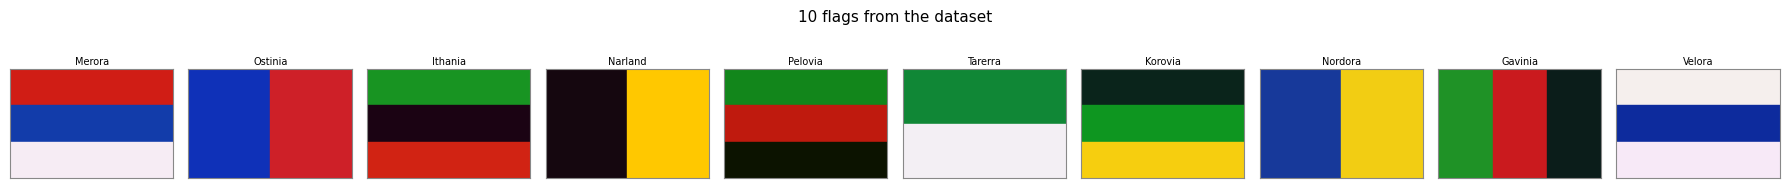

In [3]:
# ── Fictional country name generator ─────────────────────────────────────────
_PREFIXES = ['Bor', 'Val', 'Mer', 'Cal', 'Ost', 'Nord', 'Sel', 'Tar', 'Vel', 'Dra',
             'Kor', 'Alm', 'Fen', 'Gav', 'Ith', 'Lor', 'Mav', 'Nar', 'Pel', 'Rav']
_SUFFIXES = ['ia', 'ovia', 'estan', 'land', 'ora', 'ania', 'inia', 'ara', 'erra', 'ovia']

def country_name(seed):
    rng = np.random.RandomState(seed)
    return _PREFIXES[rng.randint(len(_PREFIXES))] + _SUFFIXES[rng.randint(len(_SUFFIXES))]

def draw_flag(ax, vec):
    """Draw a flag from an 11D raw (denormalized) vector.
    vec[0:9]  = 3 RGB colors, vec[9] = orientation, vec[10] = n_colors
    """
    colors      = np.clip(vec[:9].reshape(3, 3), 0, 1)
    vertical    = vec[9] > 0.5   # round the continuous prediction to binary
    two_colors  = vec[10] < 0.5

    n_stripes = 2 if two_colors else 3
    stripe_colors = colors[:n_stripes]

    if vertical:
        w = 3 / n_stripes
        for i, c in enumerate(stripe_colors):
            ax.add_patch(plt.Rectangle((i * w, 0), w, 2, color=c))
    else:
        h = 2 / n_stripes
        for i, c in enumerate(stripe_colors):
            ax.add_patch(plt.Rectangle((0, 2 - (i + 1) * h), 3, h, color=c))

    ax.set_xlim(0, 3)
    ax.set_ylim(0, 2)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#888888')
        spine.set_linewidth(0.8)

def show_flags(raw_vecs, n=10, title='Flag samples', name_seeds=None):
    """raw_vecs: array of shape (N, 11) in original (denormalized) space."""
    fig, axes = plt.subplots(1, n, figsize=(n * 1.8, 1.8))
    fig.suptitle(title, fontsize=11, y=1.05)
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        draw_flag(ax, raw_vecs[i])
        seed = name_seeds[i] if name_seeds is not None else i
        ax.set_title(country_name(int(seed)), fontsize=7, pad=3)
    plt.tight_layout()
    plt.show()

idx = np.random.choice(len(data), 10, replace=False)
show_flags(data[idx], title='10 flags from the dataset', name_seeds=idx)

## Diffusion: Forward and Reverse

**Forward process** — gradually add noise over T steps:

    x_t = (1 - β) * x_{t-1}  +  β * ε,    ε ~ N(0, I)

After T steps, x_T looks like pure Gaussian noise.

**Reverse process** — a small network predicts the noise residual at each step:

    x_{t-1}  ≈  x_t  -  f_θ(x_t, t/T)

**Training objective** — minimize MSE between predicted and actual residual:

    L = E[ ‖ f_θ(x_t, t/T)  -  (x_t - x_{t-1}) ‖² ]

**Sampling** — start from x_T ~ N(0, I), apply the reverse T times.

In [4]:
class NoiseMLP(nn.Module):
    """Predicts the noise residual given a noisy flag and the timestep."""

    def __init__(self, data_dim=11, hidden=64):
        # __init__ runs once when we create the network. We define all the
        # layers here so PyTorch knows what parameters need to be trained.
        super().__init__()  # required boilerplate to set up the nn.Module base class

        self.net = nn.Sequential(  # Sequential stacks layers in order: input → layer1 → layer2 → output
            # First layer: takes the 11 flag values + 1 timestep value = 12 numbers,
            # and outputs 64 numbers. The network learns what to put in those 64 slots.
            nn.Linear(data_dim + 1, hidden),
            nn.SiLU(),   # activation function: adds non-linearity so the network can learn curved patterns

            # Second layer: mixes the 64 numbers into a new set of 64 numbers.
            # More layers = more capacity to learn complex patterns.
            nn.Linear(hidden, hidden),
            nn.SiLU(),

            # Output layer: squashes the 64 numbers back down to 11 —
            # one predicted residual value for each dimension of the flag vector.
            nn.Linear(hidden, data_dim),
        )

    def forward(self, x, t_norm):
        # forward() defines what happens on each pass through the network.
        # x is a batch of noisy flags, shape (batch_size, 11).
        # t_norm is the timestep for each flag, shape (batch_size,) — a single number per flag.

        t_col = t_norm.unsqueeze(1)  # reshape from (batch_size,) to (batch_size, 1)
                                     # so it can be glued onto x as an extra column

        return self.net(torch.cat([x, t_col], dim=1))  # glue timestep onto flag vector,
                                                        # then run through all layers

net = NoiseMLP().to(device)  # .to(device) moves the network to GPU if available, otherwise CPU
print('Parameters:', sum(p.numel() for p in net.parameters()))  # total number of trainable weights

Parameters: 5707


In [5]:
T    = 20     # diffusion timesteps
BETA = 0.10   # noise rate per step
EPOCHS = 300

optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

def add_noise_step(x):
    """x_{t} = (1 - beta) * x_{t-1} + beta * noise"""
    return (1 - BETA) * x + BETA * torch.randn_like(x)

losses = []
net.train()

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for (x0,) in loader:
        x0 = x0.to(device)

        # Build trajectory x0 → x1 → ... → xT
        xts = [x0]
        for _ in range(T):
            xts.append(add_noise_step(xts[-1]))

        # Train on every step
        step_loss = 0.0
        for t in range(1, T + 1):
            xt     = xts[t]
            x_prev = xts[t - 1]
            t_norm = torch.full((x0.size(0),), t / T, device=device)

            residual_pred = net(xt, t_norm)
            x_prev_pred   = xt - residual_pred

            loss = F.mse_loss(x_prev_pred, x_prev)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            step_loss += loss.item()

        epoch_loss += step_loss / T

    losses.append(epoch_loss / len(loader))
    if epoch % 50 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS} | loss: {losses[-1]:.5f}')

Epoch  50/300 | loss: 0.01091
Epoch 100/300 | loss: 0.01073
Epoch 150/300 | loss: 0.01054
Epoch 200/300 | loss: 0.01038
Epoch 250/300 | loss: 0.01030
Epoch 300/300 | loss: 0.01016


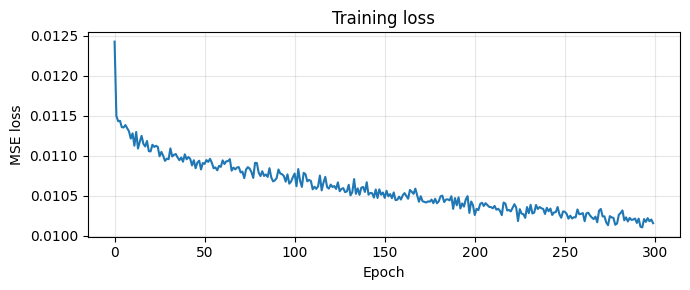

In [6]:
plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Training loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

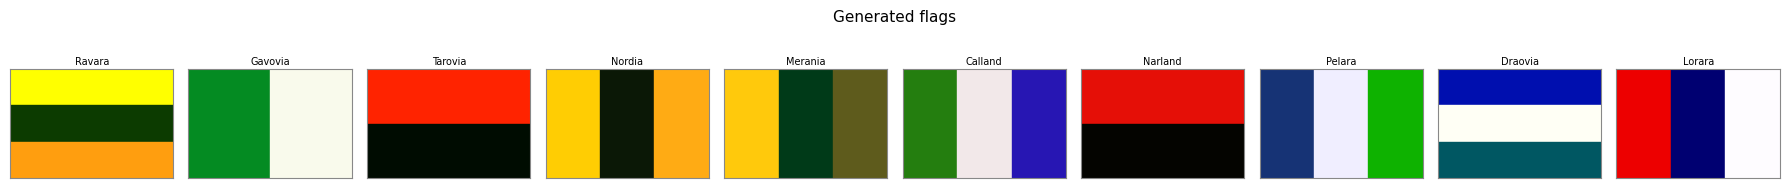

In [7]:
@torch.no_grad()
def sample_flags(n=10):
    """Generate n flags: start from pure noise, run the reverse process T times."""
    net.eval()
    x = torch.randn(n, 11, device=device)
    for t in reversed(range(1, T + 1)):
        t_norm = torch.full((n,), t / T, device=device)
        x = x - net(x, t_norm)
    return x.cpu().numpy()

generated_norm = sample_flags(n=10)

# Denormalize: RGB channels use mu/std_vals, binary features are left as-is
generated = generated_norm * std_vals + mu

show_flags(generated, title='Generated flags', name_seeds=range(1000, 1010))

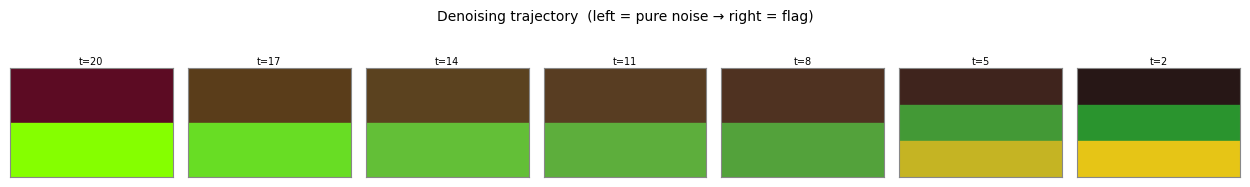

In [8]:
@torch.no_grad()
def denoising_trajectory(n_snaps=7):
    """Show one flag being born from noise, step by step."""
    net.eval()
    x = torch.randn(1, 11, device=device)

    snap_every = max(1, T // (n_snaps - 1))
    snaps = [x.cpu().numpy().copy()]
    for t in reversed(range(1, T + 1)):
        t_norm = torch.full((1,), t / T, device=device)
        x = x - net(x, t_norm)
        if t % snap_every == 0:
            snaps.append(x.cpu().numpy().copy())

    # Denormalize each snapshot
    snaps_raw = [s * std_vals + mu for s in snaps]

    fig, axes = plt.subplots(1, len(snaps_raw), figsize=(len(snaps_raw) * 1.8, 1.8))
    fig.suptitle('Denoising trajectory  (left = pure noise → right = flag)', fontsize=10, y=1.05)
    for i, (ax, vec) in enumerate(zip(axes, snaps_raw)):
        draw_flag(ax, vec[0])
        ax.set_title(f't={T - i * snap_every}', fontsize=7, pad=3)
    plt.tight_layout()
    plt.show()

denoising_trajectory()

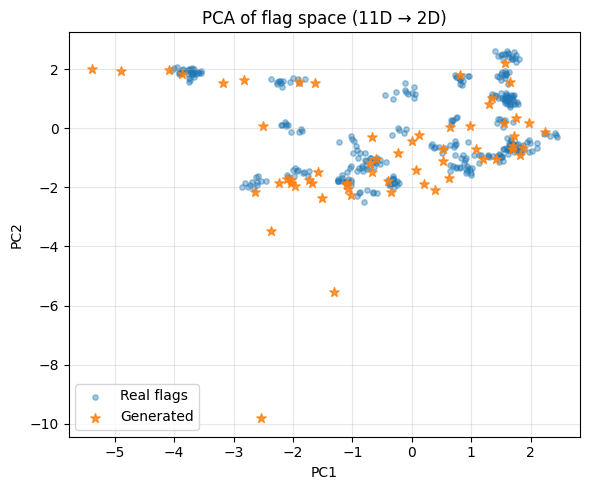

In [9]:
# Optional: PCA projection — do generated flags lie on the same manifold?
from sklearn.decomposition import PCA

gen_norm = sample_flags(n=60)

pca = PCA(n_components=2)
real_2d = pca.fit_transform(data_norm)
gen_2d  = pca.transform(gen_norm)

plt.figure(figsize=(6, 5))
plt.scatter(real_2d[:, 0], real_2d[:, 1], alpha=0.4, s=15, label='Real flags')
plt.scatter(gen_2d[:, 0],  gen_2d[:, 1],  alpha=0.8, s=50, marker='*', label='Generated')
plt.legend()
plt.title('PCA of flag space (11D → 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()